In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# df = pd.read_csv('/workspaces/k-means-repo/data/processed/cleaned_data.csv')
df = pd.read_csv('/workspaces/k-means-repo/data/processed/cleaned_data_before_encoding.csv')
print(df.shape)
df.head()

(50000, 20)


,age,brand,model,price_usd,rating,sentiment,country,language,verified_purchase,battery_life_rating,camera_rating,performance_rating,design_rating,display_rating,helpful_votes,source,price_local_value,review_month,review_day,review_year
0,45,Realme,Realme 12 Pro,337.31,2,Negative,India,Hindi,1,1,1,3,2,1,1,Amazon,27996.7300,11,6,2023
1,18,Realme,Realme 12 Pro,307.78,4,Positive,Brazil,Portuguese,1,3,2,4,3,2,5,Flipkart,1754.3460,3,30,2023
2,27,Google,Pixel 6,864.53,4,Positive,India,Hindi,1,3,5,3,2,4,8,AliExpress,71755.9900,12,7,2022
3,19,Xiaomi,Redmi Note 13,660.94,3,Positive,UAE,English,0,1,3,2,1,2,3,Amazon,2425.6498,3,11,2025
4,38,Motorola,Edge 50,792.13,3,Neutral,Brazil,Portuguese,1,3,3,2,2,1,0,BestBuy,4515.1410,9,29,2023


Bar chart ->  Counting categories
Histogram -> Numeric distributions
Scatter plot -> Two numeric columns
Pie chart -> Proportions of categories

sentiment
Negative    10656
Neutral     12035
Positive    27309
Name: count, dtype: int64


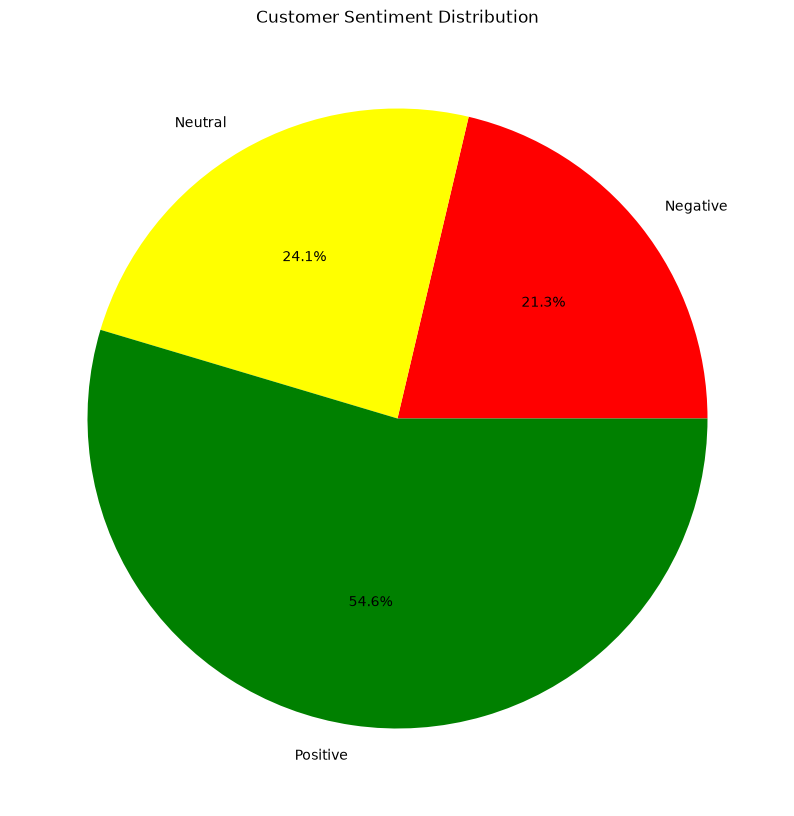

In [33]:
# visualize sentiment column

sentiment_counts = df['sentiment'].value_counts().sort_index()

print(sentiment_counts)

plt.figure(figsize=(10, 11))
plt.pie(sentiment_counts, 
        labels=['Negative', 'Neutral', 'Positive'], 
        autopct='%1.1f%%',
        colors=['red', 'yellow', 'green'])
plt.title('Customer Sentiment Distribution')
plt.show()

"54.6% positive sentiment suggests majority of customers are satisfied with their mobile purchases. However 21.3% negative sentiment means 1 in 5 customers are unhappy — which needs attention..."

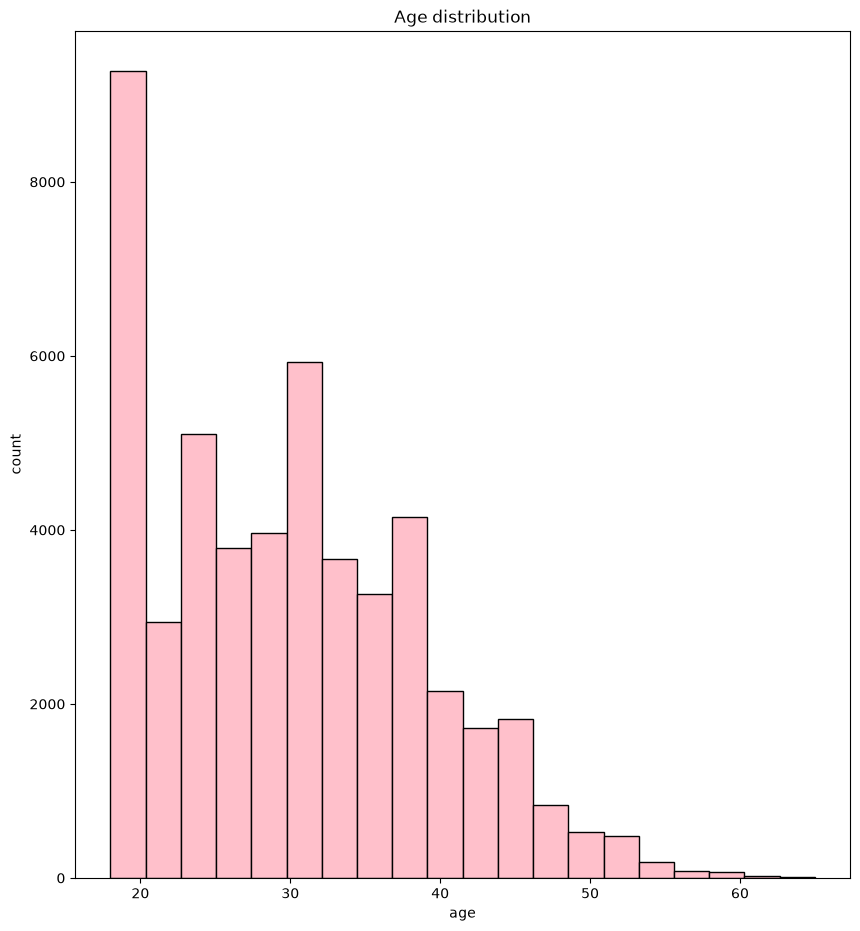

In [34]:
# visualize age column
plt.figure(figsize=(10, 11))
plt.hist(df['age'], bins=20, color='pink', edgecolor='black')
plt.title('Age distribution' )
plt.xlabel('age')
plt.ylabel('count')
plt.show()

Nearly 9,000-10,000 customers are in the 18-20 age group — the largest segment. After age 30, the count drops to roughly 1/4th, and beyond 50 it becomes very minimal.


Target your marketing towards 18-30 year olds — they are your biggest customer base! Premium or budget phones aimed at young adults will have the most impact.

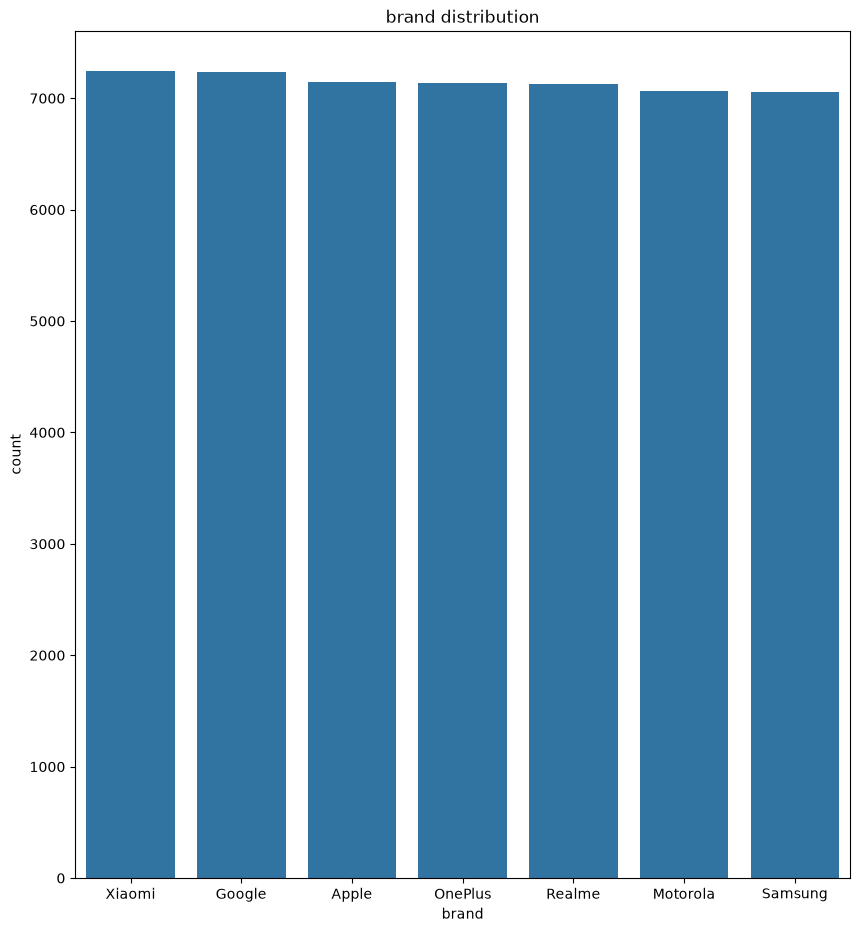

In [35]:
# visualize brand column
plt.figure(figsize=(10, 11))
sns.countplot(data=df, x='brand', order=df['brand'].value_counts().index)
plt.title('brand distribution')
plt.xlabel('brand')
plt.ylabel('count')
plt.show()

The dataset is well balanced across all brands — no single brand dominates the reviews. This means clustering results will not be biased towards any particular brand!

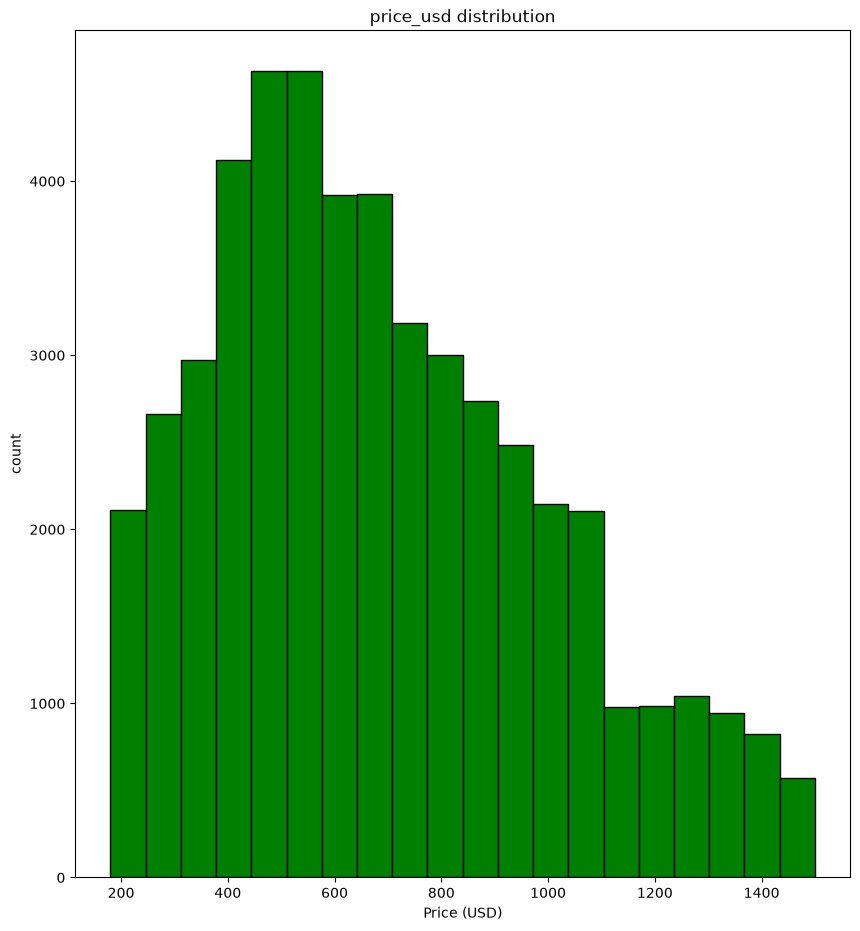

In [36]:
# visualize price_usd  column
plt.figure(figsize=(10, 11))
plt.hist(df['price_usd'], bins=20, color='green', edgecolor='black')
plt.title('price_usd distribution' )
plt.xlabel('Price (USD)')
plt.ylabel('count')
plt.show()

Most customers buy phones in the $400-$600 range — the peak of the chart!

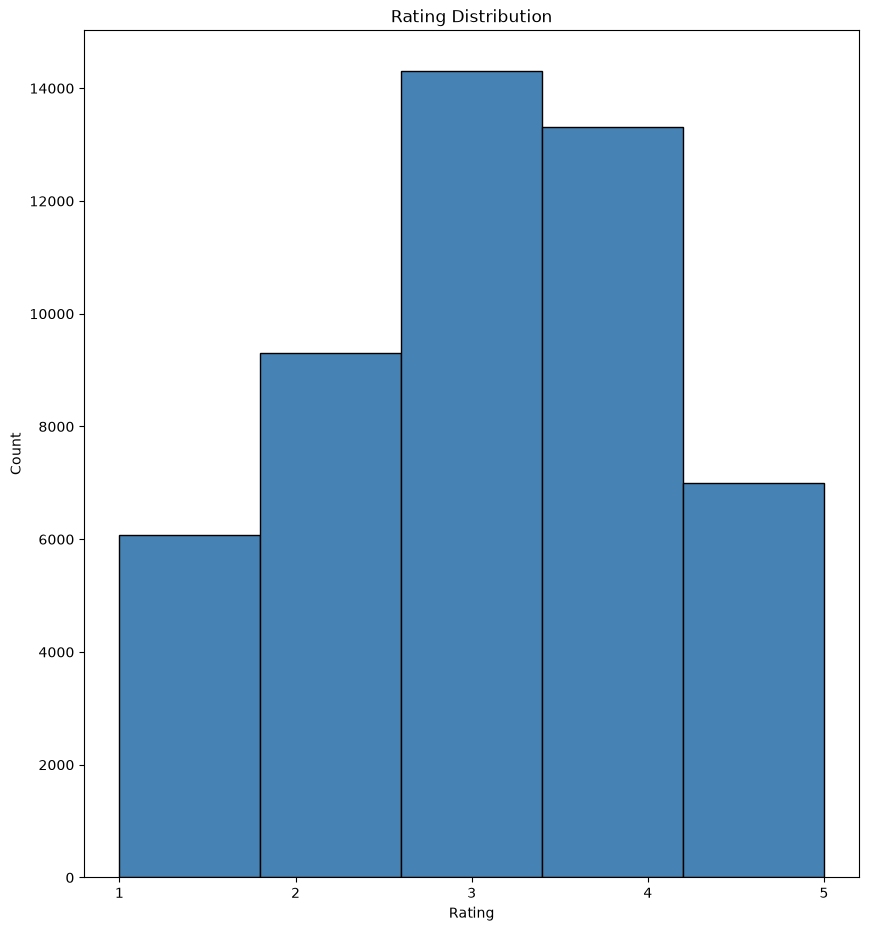

In [37]:
# visualize rating column
plt.figure(figsize=(10, 11))
plt.hist(df['rating'], bins=5, color='steelblue', edgecolor='black')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks([1, 2, 3, 4, 5])
plt.show()

Univariate EDA Summary 📊
1. Sentiment Distribution

54.6% customers are Positive, 24.1% Neutral, 21.3% Negative. More than half of mobile customers are satisfied with their purchases!

2. Age Distribution

Majority of buyers are aged 18-30. Mobile brands should focus marketing towards young adults as they are the biggest customer segment!

3. Brand Distribution

All 7 brands are equally represented with ~7,000 reviews each. Dataset is well balanced — clustering will not be biased towards any brand!

4. Price Distribution

Most customers buy mid-range phones ($400-$600). Very few buy premium phones above $1,200 — showing high price sensitivity in the market!

5. Rating Distribution

Most customers give rating 3-4 out of 5. Very few give extreme ratings (1 or 5) — consistent with the neutral-positive sentiment trend!

Bivariate analysis

chart -> Best for
Histogram -> Numeric distribution
Scatter plot -> Two numeric columns
Grouped bar chart -> Two categorical columns
Box plot -> Numeric vs categorical

<StringArray>
['Negative', 'Positive', 'Neutral']
Length: 3, dtype: str


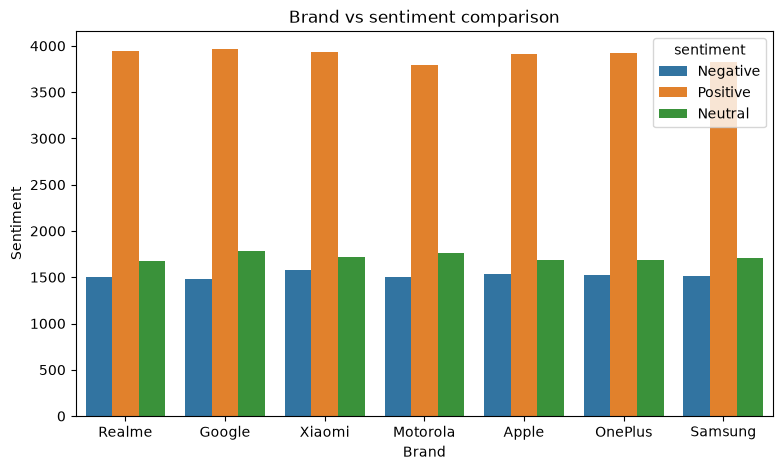

In [38]:
# brand vs sentiment
print(df['sentiment'].unique())

plt.figure(figsize=(9,5))
sns.countplot(data = df, x = 'brand', hue = 'sentiment' )
plt.title("Brand vs sentiment comparison")
plt.xlabel("Brand")
plt.ylabel("Sentiment")
plt.legend(title = "sentiment" )
plt.show()

More positive reviews across all the brands and around 3000 neutral commands and less negative commands across all the brands.

No single brand stands out as particularly better or worse in customer sentiment — all brands have consistently high positive reviews. This suggests product quality is fairly uniform across brands in this dataset!

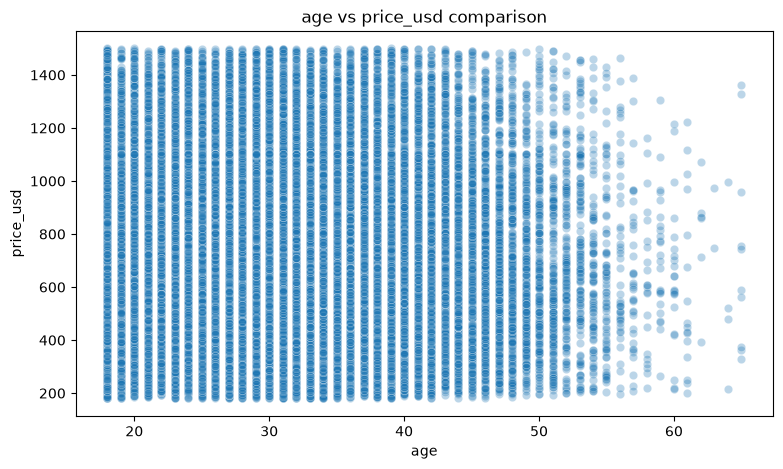

In [39]:
# age vs price_usd
plt.figure(figsize=(9,5))
sns.scatterplot(data = df, x = "age", y = "price_usd", alpha = 0.3)
plt.title("age vs price_usd comparison")
plt.xlabel("age")
plt.ylabel("price_usd")
plt.show()

Elderly people i.e aged people above 50 spend less amount for mobile. So business should focus more on age below 50

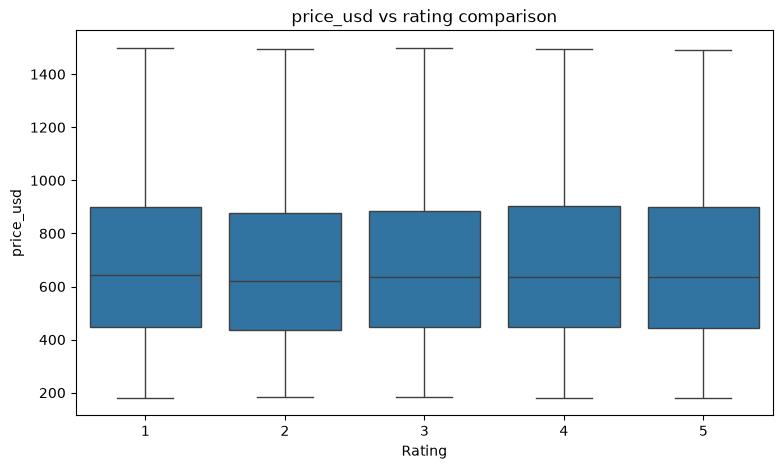

In [40]:
# price_usd vs rating
df_sample = df.sample(10000, random_state=42)
plt.figure(figsize=(9,5))
sns.boxplot(data=df_sample, x='rating', y='price_usd')
plt.title("price_usd vs rating comparison")
plt.xlabel("Rating")
plt.ylabel("price_usd")
plt.show()



Price does NOT influence rating! Whether a customer pays $200 or $1400 — they give similar ratings!

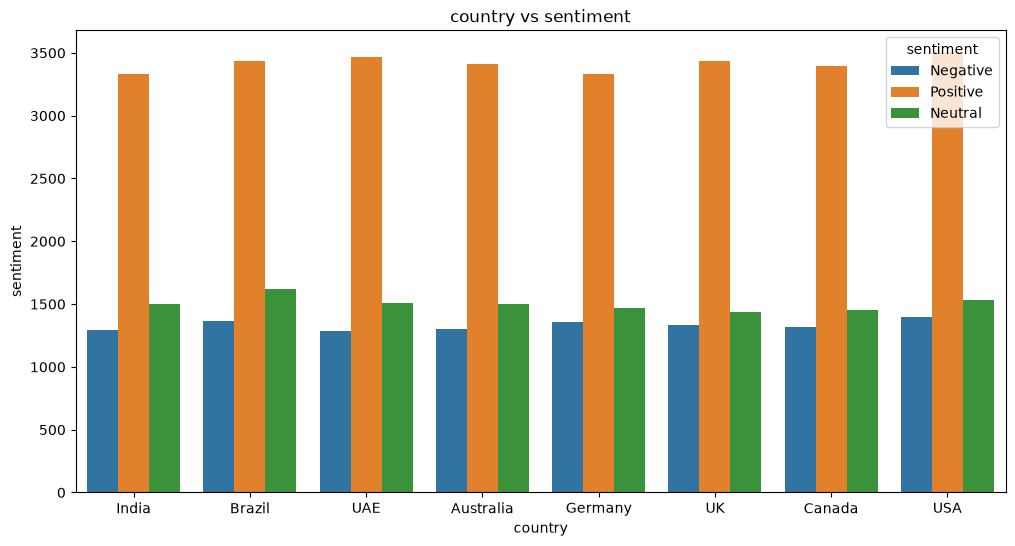

In [41]:
# country vs sentiment
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='country', hue='sentiment')
plt.title('country vs sentiment')
plt.xlabel('country')
plt.ylabel('sentiment')
plt.legend(title='sentiment')
plt.show()

Positive sentiment dominates across ALL countries — no single country is significantly more satisfied or dissatisfied than others!

Analysis -> Insight

Sentiment -> 54.6% positive globally 
Age -> Young buyers (18-30) dominate
Brand -> All brands equally represented
Price -> Mid-range ($400-$600) most popular
Rating -> Most give 3-4 stars
Brand vs Sentiment -> All brands get similar positive reviews
Age vs Price -> Older customers spend less
Price vs Rating -> Price does NOT affect rating!
Country vs Sentiment -> All countries equally positive